In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
##đọc file csv 
df=pd.read_csv(r'C:\project\KPDL\sales_data.csv')

In [6]:
##Tổng thể về df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13274 entries, 0 to 13273
Data columns (total 75 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            13274 non-null  int64  
 1   listing_url                                   13274 non-null  object 
 2   scrape_id                                     13274 non-null  int64  
 3   last_scraped                                  13274 non-null  object 
 4   source                                        13274 non-null  object 
 5   name                                          13274 non-null  object 
 6   description                                   13013 non-null  object 
 7   neighborhood_overview                         7680 non-null   object 
 8   picture_url                                   13274 non-null  object 
 9   host_id                                       13274 non-null 

In [8]:
## 5 dòng đầu của df
df.head(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,10595,https://www.airbnb.com/rooms/10595,20240626035544,2024-06-26,city scrape,"3 bedrooms, 2 bathrooms, 2nd floor with elevator",The apartment is 3-bedroom apartment with 2-ba...,Ampelokipi district is nice multinational and ...,https://a0.muscache.com/pictures/hosting/Hosti...,37177,...,4.90,4.58,4.75,00002433180,t,7,7,0,0,0.33
1,10990,https://www.airbnb.com/rooms/10990,20240626035544,2024-06-26,city scrape,Athens Quality Apartments - Deluxe Apartment,Athens Quality Apartments - Deluxe apartment i...,Ampelokipi district is nice multinational and ...,https://a0.muscache.com/pictures/miso/Hosting-...,37177,...,4.90,4.81,4.75,00002433169,t,7,7,0,0,0.54
2,10993,https://www.airbnb.com/rooms/10993,20240626035544,2024-06-26,city scrape,Athens Quality Apartments - Studio,The Studio is an <br />-excellent located <br ...,Ampelokipi district is nice multinational and ...,https://a0.muscache.com/pictures/107309527/848...,37177,...,4.98,4.82,4.78,00002433010,t,7,7,0,0,0.67
3,10995,https://www.airbnb.com/rooms/10995,20240626035544,2024-06-26,city scrape,"AQA-No2 1-bedroom, smart tv, fiber connection,","AQA No2 is 1-bedroom apartment (47m2), on the ...",Ampelokipi district is nice multinational and ...,https://a0.muscache.com/pictures/hosting/Hosti...,37177,...,4.87,4.83,4.80,00002433153,t,7,7,0,0,0.19
4,27262,https://www.airbnb.com/rooms/27262,20240626035544,2024-06-26,city scrape,Athens Quality Apartments - Ground floor apart...,THE MATTRESS - KING KOIL - Camden Luxury 160x2...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,37177,...,4.96,4.75,4.71,00002433111,t,7,7,0,0,0.17


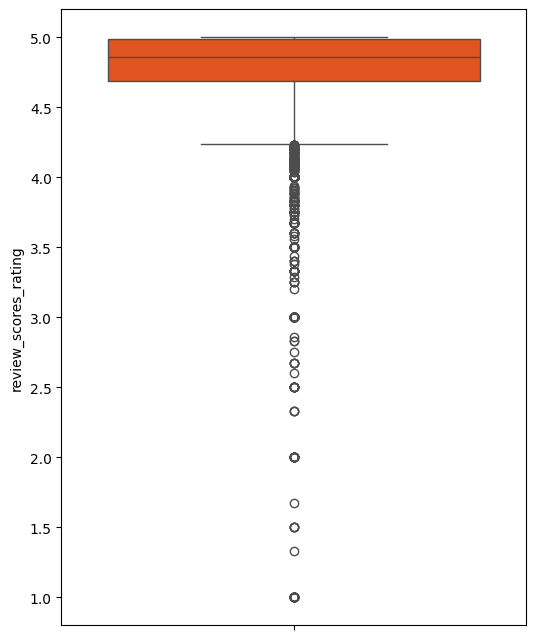

In [4]:
##Các phòng trong dịch vụ hầu như đều được đánh giá cao nhưng có 1 số lượng nhỏ phòng được đánh giá thấp. Vây nguyên nhân là do đâu
plt.figure(figsize=(6,8))
sns.boxplot(df['review_scores_rating'],color='orangered')
plt.show()

In [7]:
##Chọn ra các cột từ df để dễ dàng cho việc phân tích và tìm nguyên nhân 
df1=df[['id','room_type','neighbourhood','price','review_scores_rating','review_scores_cleanliness','review_scores_communication']]

In [8]:
##Thông tin các cột đã được lọc ra
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13274 entries, 0 to 13273
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           13274 non-null  int64  
 1   room_type                    13274 non-null  object 
 2   neighbourhood                7680 non-null   object 
 3   price                        13068 non-null  object 
 4   review_scores_rating         11509 non-null  float64
 5   review_scores_cleanliness    11489 non-null  float64
 6   review_scores_communication  11489 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 726.0+ KB


In [9]:
## chuyển cột 'id' về định dạng chuỗi
df1['id']=df1['id'].astype('str')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13216\214958980.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['id']=df1['id'].astype('str')


In [10]:
df1['price'] = df1['price'].str.replace('$', '').str.replace(',', '')
df1['price'] = df1['price'].astype('float')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13216\3133406852.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['price'] = df1['price'].str.replace('$', '').str.replace(',', '')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13216\3133406852.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['price'] = df1['price'].astype('float')


In [12]:
##Tạo 1 file csv mới chứa các cột đã được lấy ra
df1.to_csv('C:\project\KPDL\sales_dataupdate.csv')

In [14]:
##Lọc ra các phòng có điểm đánh giá từ 1 đến dưới 3 điểm
df2=df1[(df1['review_scores_rating']>=1.0) & (df1['review_scores_rating']<3.0)]

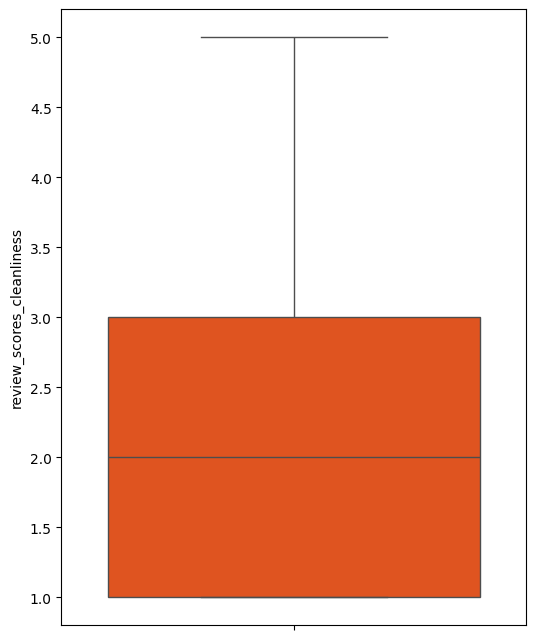

In [16]:
##Khách hàng không hài lòng về sự vệ sinh trong các căn phòng đó
plt.figure(figsize=(6,8))
sns.boxplot(df2['review_scores_cleanliness'],color='orangered')
plt.show()

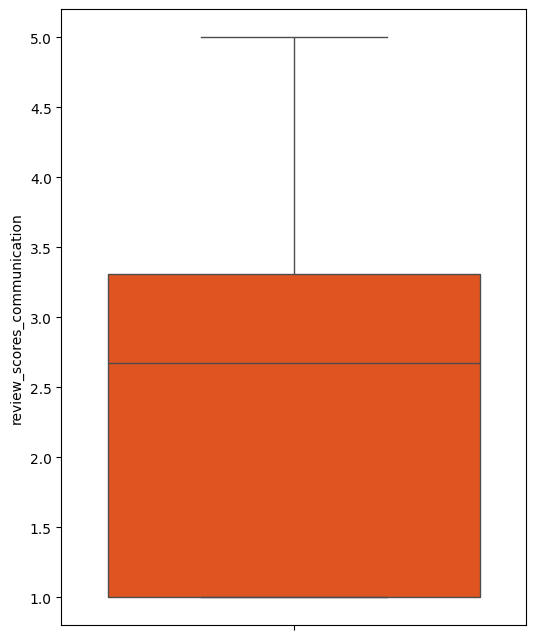

In [18]:
##Khách hàng cũng không hài lòng về sự giao tiếp với các chủ phòng của các phòng đó
plt.figure(figsize=(6,8))
sns.boxplot(df2['review_scores_communication'],color='orangered')
plt.show()